In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — TRAINING: Color Identifier CNN  (VERSION 3)
#
# Changes from V2:
#   - CIFAR-10 (32x32) replaced with STL-10 (96x96) → less upscale blur
#   - Confidence threshold kept (MIN_DOMINANCE=0.30)
#   - 4 clean synthetic generators (blob + multi-color removed)
#   - Gradient generator vectorized (was O(N²) pixel loop)
#   - V1 architecture restored (no in-model augmentation layers)
#   - Offline horizontal flip only (safe for color labels)
#   - Fixed type inconsistency in random_color_for_class() Neutral case
# ═══════════════════════════════════════════════════════════════
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers, models

# ─────────────────────────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────────────────────────
IMG_SIZE       = 128
NUM_CLASSES    = 10
BATCH_SIZE     = 16
EPOCHS         = 30
N_STL_TRAIN    = 20000   # images to sample from STL-10 unlabelled (100K total)
N_STL_TEST     = 3000    # images to sample for test set
N_SYNTH        = 4000    # synthetic training images
N_SYNTH_TEST   = 1000    # synthetic test images
MIN_DOMINANCE  = 0.30    # discard CIFAR/STL images with no clear dominant color

CLASS_NAMES = [
    'Neutral', 'Red', 'Orange', 'Yellow', 'Green',
    'Cyan',    'Blue', 'Violet', 'Pink',   'Brown'
]

# ─────────────────────────────────────────────────────────────────
# XKCD Color Survey — 949 crowdsourced color names with RGB values
# Source: https://xkcd.com/color/rgb/
# Accessed via matplotlib.colors.XKCD_COLORS (not hardcoded)
# ─────────────────────────────────────────────────────────────────
xkcd_raw = mcolors.XKCD_COLORS
print(f"Loaded {len(xkcd_raw)} XKCD survey colors\n")

xkcd_names, xkcd_rgb = [], []
for name, hex_val in xkcd_raw.items():
    r, g, b = mcolors.to_rgb(hex_val)
    xkcd_names.append(name.replace('xkcd:', ''))
    xkcd_rgb.append([int(r * 255), int(g * 255), int(b * 255)])
xkcd_rgb = np.array(xkcd_rgb, dtype=np.uint8)

# ─────────────────────────────────────────────────────────────────
# Map XKCD colors → 10 classes via keyword matching
# ─────────────────────────────────────────────────────────────────
KEYWORD_MAP = {
    0: ['grey', 'gray', 'white', 'black', 'silver', 'charcoal',
        'gunmetal', 'ash', 'slate', 'steel', 'iron'],
    1: ['red', 'scarlet', 'crimson', 'vermillion', 'ruby',
        'cherry', 'blood', 'brick', 'fire engine', 'tomato',
        'wine', 'burgundy', 'maroon'],
    2: ['orange', 'tangerine', 'peach', 'apricot', 'amber',
        'marigold', 'pumpkin', 'melon'],
    3: ['yellow', 'gold', 'lemon', 'mustard', 'canary',
        'dandelion', 'butter', 'sunflower', 'banana', 'straw'],
    4: ['green', 'lime', 'olive', 'forest', 'sage', 'mint',
        'emerald', 'jade', 'fern', 'moss', 'grass', 'pea',
        'avocado', 'pistachio', 'shamrock', 'seaweed', 'kelp',
        'chartreuse', 'clover', 'juniper', 'pine', 'swamp'],
    5: ['cyan', 'teal', 'turquoise', 'aqua', 'aquamarine',
        'seafoam', 'sea foam'],
    6: ['blue', 'navy', 'cobalt', 'azure', 'indigo', 'cerulean',
        'cornflower', 'denim', 'periwinkle', 'sapphire', 'sky',
        'ocean', 'royal blue', 'baby blue'],
    7: ['violet', 'purple', 'lavender', 'plum', 'magenta',
        'mauve', 'lilac', 'eggplant', 'grape', 'iris',
        'amethyst', 'orchid', 'heather', 'mulberry'],
    8: ['pink', 'rose', 'fuchsia', 'salmon', 'blush',
        'hot pink', 'bubblegum', 'carnation', 'coral',
        'watermelon', 'strawberry', 'flamingo', 'barbie'],
    9: ['brown', 'tan', 'beige', 'khaki', 'chocolate', 'umber',
        'sienna', 'coffee', 'mocha', 'caramel', 'taupe',
        'sand', 'clay', 'dirt', 'mud', 'cinnamon', 'chestnut',
        'cocoa', 'camel', 'peanut', 'rust', 'copper', 'bronze',
        'mahogany'],
}

xkcd_labels = np.full(len(xkcd_names), -1, dtype=np.int32)
for cls_id, keywords in KEYWORD_MAP.items():
    for i, name in enumerate(xkcd_names):
        if xkcd_labels[i] != -1:
            continue
        for kw in keywords:
            if kw in name:
                xkcd_labels[i] = cls_id
                break

matched   = (xkcd_labels != -1).sum()
unmatched = (xkcd_labels == -1).sum()
print(f"Keyword-matched: {matched} / {len(xkcd_names)}")
print(f"Unmatched: {unmatched} (will assign via CIELAB nearest-neighbor)\n")

# ─────────────────────────────────────────────────────────────────
# Convert XKCD colors to CIELAB, compute data-driven class centroids
# ─────────────────────────────────────────────────────────────────
def rgb_array_to_lab(rgb_arr):
    """Convert Nx3 uint8 RGB array to Nx3 CIELAB float array (single cv2 call)."""
    img_rgb = rgb_arr.reshape(-1, 1, 3).astype(np.uint8)
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab).astype(np.float32)
    L = img_lab[:, 0, 0] * (100.0 / 255.0)
    a = img_lab[:, 0, 1] - 128.0
    b = img_lab[:, 0, 2] - 128.0
    return np.stack([L, a, b], axis=-1)

xkcd_lab = rgb_array_to_lab(xkcd_rgb)

# Initial centroids from keyword-matched colors
centroids = np.zeros((NUM_CLASSES, 3), dtype=np.float32)
for cls in range(NUM_CLASSES):
    idx = np.where(xkcd_labels == cls)[0]
    if len(idx) > 0:
        centroids[cls] = xkcd_lab[idx].mean(axis=0)

# Assign unmatched colors to nearest centroid
for i in np.where(xkcd_labels == -1)[0]:
    dists = np.sqrt(np.sum((centroids - xkcd_lab[i]) ** 2, axis=1))
    xkcd_labels[i] = int(np.argmin(dists))

# Recompute final centroids with all colors assigned
REF_LAB = np.zeros((NUM_CLASSES, 3), dtype=np.float32)
for cls in range(NUM_CLASSES):
    idx = np.where(xkcd_labels == cls)[0]
    REF_LAB[cls] = xkcd_lab[idx].mean(axis=0)

print("XKCD-derived class centroids (CIELAB):")
for i, name in enumerate(CLASS_NAMES):
    count = (xkcd_labels == i).sum()
    C = np.sqrt(REF_LAB[i, 1]**2 + REF_LAB[i, 2]**2)
    print(f"  {i:2d} {name:<8s}  L*={REF_LAB[i,0]:5.1f}  a*={REF_LAB[i,1]:+6.1f}  "
          f"b*={REF_LAB[i,2]:+6.1f}  C*={C:.1f}  ({count} XKCD colors)")

# Chroma threshold: 90th percentile of XKCD neutrals' chroma values
neutral_idx     = np.where(xkcd_labels == 0)[0]
neutral_chromas = np.sqrt(xkcd_lab[neutral_idx, 1]**2 + xkcd_lab[neutral_idx, 2]**2)
CHROMA_THRESHOLD = float(np.percentile(neutral_chromas, 90))
print(f"\nChroma threshold (XKCD neutrals, 90th pct): {CHROMA_THRESHOLD:.1f}")

# ─────────────────────────────────────────────────────────────────
# Labeling function — dominant color with confidence threshold
# Intentional design: REF_LAB[1:] skips Neutral in distance calc;
# Neutral is handled separately by chroma threshold, then +1 offset
# corrects indices back to 1-9.
# ─────────────────────────────────────────────────────────────────
def label_dominant_color(img_rgb, min_dominance=0.0):
    """Return (dominant_class, dominance_ratio) or (None, ratio) if ambiguous."""
    bgr    = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    lab_cv = cv2.cvtColor(bgr, cv2.COLOR_BGR2Lab).astype(np.float32)
    L      = lab_cv[:, :, 0].ravel() * (100.0 / 255.0)
    a      = lab_cv[:, :, 1].ravel() - 128.0
    b      = lab_cv[:, :, 2].ravel() - 128.0
    chroma = np.sqrt(a**2 + b**2)

    pix_lab = np.stack([L, a, b], axis=1)
    # Distance to 9 chromatic centroids (skip Neutral — handled by chroma threshold)
    diff    = pix_lab[:, np.newaxis, :] - REF_LAB[np.newaxis, 1:, :]
    delta_e = np.sqrt(np.sum(diff**2, axis=2))
    nearest = np.argmin(delta_e, axis=1).astype(np.uint8) + 1  # +1 → indices 1-9
    labels  = np.where(chroma < CHROMA_THRESHOLD, 0, nearest)

    counts = np.bincount(labels, minlength=NUM_CLASSES)
    total  = counts.sum()

    chromatic_counts = counts.copy()
    chromatic_counts[0] = 0
    if chromatic_counts.sum() > 0:
        dominant  = int(np.argmax(chromatic_counts))
        dominance = counts[dominant] / total
    else:
        dominant  = 0
        dominance = counts[0] / total

    if dominance < min_dominance:
        return None, dominance
    return dominant, dominance

# ─────────────────────────────────────────────────────────────────
# Synthetic image generators — 4 clean types
# (blob + multi-color removed: unreliable label coverage)
# ─────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

def lab_to_srgb(L_star, a_star, b_star):
    L_cv = float(np.clip(L_star * 255.0 / 100.0, 0, 255))
    a_cv = float(np.clip(a_star + 128.0, 0, 255))
    b_cv = float(np.clip(b_star + 128.0, 0, 255))
    lab_u8 = np.array([[[L_cv, a_cv, b_cv]]], dtype=np.uint8)
    bgr    = cv2.cvtColor(lab_u8, cv2.COLOR_Lab2BGR)
    return bgr[0, 0, ::-1]  # returns uint8 RGB (3,)

def random_color_for_class(cls):
    """Generate a random uint8 RGB color for the given class."""
    ref_L, ref_a, ref_b = REF_LAB[cls]
    if cls == 0:  # Neutral — low chroma, any lightness
        L     = float(np.clip(rng.uniform(10, 95), 5, 98))
        a_new = float(rng.uniform(-3.0, 3.0))   # fixed: wrapped in float
        b_new = float(rng.uniform(-3.0, 3.0))   # fixed: wrapped in float
    else:
        angle  = np.arctan2(ref_b, ref_a) + rng.uniform(-np.pi / 6, np.pi / 6)
        chroma = float(np.clip(np.sqrt(ref_a**2 + ref_b**2) + rng.normal(0, 10), 20, 100))
        L      = float(np.clip(ref_L + rng.normal(0, 12), 12, 95))
        a_new  = float(chroma * np.cos(angle))
        b_new  = float(chroma * np.sin(angle))
    return lab_to_srgb(L, a_new, b_new)

# TYPE 1: Solid patch with noise (proven from V1)
def gen_solid_patch(cls):
    color = random_color_for_class(cls)
    img   = np.full((IMG_SIZE, IMG_SIZE, 3), color, dtype=np.uint8)
    noise = rng.integers(-10, 11, size=img.shape, dtype=np.int16)
    return np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# TYPE 2: Gradient patch — vectorized (fixed from V2's O(N²) loop)
def gen_gradient_patch(cls):
    c1 = random_color_for_class(cls).astype(np.float32)
    c2 = random_color_for_class(cls).astype(np.float32)
    t  = np.linspace(0, 1, IMG_SIZE, dtype=np.float32)
    if rng.integers(0, 2) == 0:
        grad = t[np.newaxis, :, np.newaxis]   # horizontal
    else:
        grad = t[:, np.newaxis, np.newaxis]   # vertical
    img   = c1 * (1.0 - grad) + c2 * grad
    noise = rng.integers(-6, 7, size=(IMG_SIZE, IMG_SIZE, 3), dtype=np.int16)
    return np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# TYPE 3: Textured patch — smooth noise tinted to class color (clean labels)
def gen_textured_patch(cls):
    color       = random_color_for_class(cls).astype(np.float32)
    noise_size  = int(rng.integers(4, 16))
    noise_field = rng.uniform(0.6, 1.4, size=(noise_size, noise_size)).astype(np.float32)
    noise_field = cv2.resize(noise_field, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
    img   = color[np.newaxis, np.newaxis, :] * noise_field[:, :, np.newaxis]
    noise = rng.integers(-8, 9, size=(IMG_SIZE, IMG_SIZE, 3), dtype=np.int16)
    return np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# TYPE 4: Two-color patch — 75% target class, 25% other (guaranteed dominance)
def gen_twocolor_patch(cls):
    img      = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    bg_color = random_color_for_class(cls)
    img[:]   = bg_color
    # One quadrant (exactly 25%) filled with a different color
    other_color = random_color_for_class(int(rng.integers(0, NUM_CLASSES)))
    half        = IMG_SIZE // 2
    quadrant    = int(rng.integers(0, 4))
    if quadrant == 0:   img[:half, :half]   = other_color
    elif quadrant == 1: img[:half, half:]   = other_color
    elif quadrant == 2: img[half:, :half]   = other_color
    else:               img[half:, half:]   = other_color
    noise = rng.integers(-5, 6, size=img.shape, dtype=np.int16)
    return np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

SYNTH_GENERATORS = [
    gen_solid_patch,
    gen_gradient_patch,
    gen_textured_patch,
    gen_twocolor_patch,
]

# ─────────────────────────────────────────────────────────────────
# Load STL-10 unlabelled set (100K images at 96x96)
# First run downloads ~2.6 GB; subsequent runs load from cache.
# ─────────────────────────────────────────────────────────────────
print("\nLoading STL-10 unlabelled …")
stl_ds = tfds.load('stl10', split='unlabelled', as_supervised=False,
                   shuffle_files=True)

# Collect raw numpy images (cap at N_STL_TRAIN + N_STL_TEST)
stl_images = []
total_needed = N_STL_TRAIN + N_STL_TEST
for sample in stl_ds.take(total_needed):
    img = sample['image'].numpy()   # uint8 (96, 96, 3) RGB
    stl_images.append(img)
    if len(stl_images) % 5000 == 0:
        print(f"  collected {len(stl_images)} STL-10 images …")

print(f"  total collected: {len(stl_images)}")

stl_train_raw = stl_images[:N_STL_TRAIN]
stl_test_raw  = stl_images[N_STL_TRAIN:]

# ─────────────────────────────────────────────────────────────────
# Label STL-10 images with confidence filtering
# ─────────────────────────────────────────────────────────────────
def build_filtered_dataset(raw_images, min_dom=MIN_DOMINANCE):
    """Resize, label and filter real images. Discards ambiguous ones."""
    imgs, labels, skipped = [], [], 0
    for img in raw_images:
        r = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
        cls, dom = label_dominant_color(r, min_dominance=min_dom)
        if cls is None:
            skipped += 1
            continue
        imgs.append(r)
        labels.append(cls)
    X = np.array(imgs, dtype=np.float32) / 255.0
    y = np.array(labels, dtype=np.int32)
    return X, y, skipped

print(f"\nLabeling STL-10 train images (confidence ≥ {MIN_DOMINANCE:.0%}) …")
X_stl, y_stl, skip_train = build_filtered_dataset(stl_train_raw)
print(f"  Kept: {len(X_stl)} / {N_STL_TRAIN}  (discarded {skip_train} ambiguous)")

print(f"Labeling STL-10 test images (confidence ≥ {MIN_DOMINANCE:.0%}) …")
X_test_stl, y_test_stl, skip_test = build_filtered_dataset(stl_test_raw)
print(f"  Kept: {len(X_test_stl)} / {N_STL_TEST}  (discarded {skip_test} ambiguous)")

# ─────────────────────────────────────────────────────────────────
# Generate diverse synthetic images (4 clean types)
# ─────────────────────────────────────────────────────────────────
print(f"\nGenerating {N_SYNTH} synthetic training images (4 types) …")
synth_imgs, synth_labels = [], []
for i in range(N_SYNTH):
    cls    = int(rng.integers(0, NUM_CLASSES))
    gen_fn = SYNTH_GENERATORS[i % len(SYNTH_GENERATORS)]
    synth_imgs.append(gen_fn(cls))
    synth_labels.append(cls)
X_synth = np.array(synth_imgs, dtype=np.float32) / 255.0
y_synth = np.array(synth_labels, dtype=np.int32)

print(f"Generating {N_SYNTH_TEST} synthetic test images …")
synth_test_imgs, synth_test_labels = [], []
for i in range(N_SYNTH_TEST):
    cls    = int(rng.integers(0, NUM_CLASSES))
    gen_fn = SYNTH_GENERATORS[i % len(SYNTH_GENERATORS)]
    synth_test_imgs.append(gen_fn(cls))
    synth_test_labels.append(cls)
X_test_synth = np.array(synth_test_imgs, dtype=np.float32) / 255.0
y_test_synth = np.array(synth_test_labels, dtype=np.int32)

# ─────────────────────────────────────────────────────────────────
# Offline augmentation — horizontal flip (safe: preserves color label)
# ─────────────────────────────────────────────────────────────────
X_stl_flip   = X_stl[:, :, ::-1, :]
X_synth_flip = X_synth[:, :, ::-1, :]

X_train = np.concatenate([X_stl, X_stl_flip, X_synth, X_synth_flip], axis=0)
y_train = np.concatenate([y_stl, y_stl,      y_synth, y_synth],      axis=0)
X_test  = np.concatenate([X_test_stl, X_test_synth], axis=0)
y_test  = np.concatenate([y_test_stl, y_test_synth], axis=0)

print(f"\nTotal training : {len(X_train)}")
print(f"  STL-10 kept  : {len(X_stl)} × 2 (+ flip) = {len(X_stl)*2}")
print(f"  Synthetic    : {len(X_synth)} × 2 (+ flip) = {len(X_synth)*2}")
print(f"Total test     : {len(X_test)}")

print("\nClass distribution in training labels:")
for cid in range(NUM_CLASSES):
    n   = (y_train == cid).sum()
    pct = n / len(y_train) * 100
    print(f"  {cid:2d} {CLASS_NAMES[cid]:<8s}  {n:5d}  ({pct:.1f}%)")

# Show sample synthetic images
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
type_names = ['Solid', 'Gradient', 'Textured', 'Two-color']
for row in range(2):
    for col in range(4):
        cls = (row * 4 + col + 1) % NUM_CLASSES
        img = SYNTH_GENERATORS[col](cls)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'{type_names[col]}\n{CLASS_NAMES[cls]}', fontsize=9)
        axes[row, col].axis('off')
plt.suptitle('V3 Synthetic Samples (4 generator types)', fontsize=12)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────
# Weighted loss (handles class imbalance)
# ─────────────────────────────────────────────────────────────────
counts = np.array([(y_train == c).sum() for c in range(NUM_CLASSES)], dtype=np.float64)
counts = np.maximum(counts, 1)
freq_weights        = 1.0 / counts
freq_weights        = freq_weights / freq_weights[1:].mean()
freq_weights[0]     = min(freq_weights[0], 0.3)

print("\nAuto-computed class weights:")
for i, (name, w) in enumerate(zip(CLASS_NAMES, freq_weights)):
    print(f"  {i:2d} {name:<8s}  {w:.3f}")

class_weight_dict = {i: float(freq_weights[i]) for i in range(NUM_CLASSES)}

# ─────────────────────────────────────────────────────────────────
# CNN Classifier — V1 architecture (no augmentation layers in model)
# ─────────────────────────────────────────────────────────────────
def build_classifier(num_classes=NUM_CLASSES):
    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))

    # Conv Block 1
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Conv Block 2
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Conv Block 3
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)

model = build_classifier()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

# ─────────────────────────────────────────────────────────────────
# Training
# ─────────────────────────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
]

print("\nTraining (V3 — STL-10 + confidence filter + diverse synth + offline flip) …")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    shuffle=True,
)

# ─────────────────────────────────────────────────────────────────
# Training curves
# ─────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['loss'],         label='Train Loss')
ax1.plot(history.history['val_loss'],     label='Val Loss')
ax1.set_title('Loss');     ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(history.history['accuracy'],     label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.suptitle('Color Identifier V3 — Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

# Sanity check on random test images
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax in axes.flat:
    idx      = np.random.randint(0, len(X_test))
    img      = (X_test[idx] * 255).astype(np.uint8)
    pred     = model.predict(X_test[idx:idx+1], verbose=0)
    pred_cls = np.argmax(pred[0])
    gt_cls   = y_test[idx]
    color    = 'green' if pred_cls == gt_cls else 'red'
    ax.imshow(img)
    ax.set_title(f"GT:{CLASS_NAMES[gt_cls]}\nP:{CLASS_NAMES[pred_cls]}",
                 fontsize=8, color=color)
    ax.axis('off')
plt.suptitle('Color Identifier V3 — Sanity Check (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.show()

# Final accuracy
val_loss, val_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal validation accuracy: {val_acc:.1%}")
print(f"Final validation loss:     {val_loss:.4f}")

model.save('color_identifier.keras')
print("Model saved → color_identifier.keras")

Loaded 949 XKCD survey colors

Keyword-matched: 844 / 949
Unmatched: 105 (will assign via CIELAB nearest-neighbor)

XKCD-derived class centroids (CIELAB):
   0 Neutral   L*= 57.0  a*=  -3.1  b*=  +1.4  C*=3.4  (70 XKCD colors)
   1 Red       L*= 40.2  a*= +57.3  b*= +33.1  C*=66.1  (77 XKCD colors)
   2 Orange    L*= 65.6  a*= +31.9  b*= +56.9  C*=65.2  (47 XKCD colors)
   3 Yellow    L*= 83.6  a*= -13.1  b*= +70.4  C*=71.6  (95 XKCD colors)
   4 Green     L*= 67.0  a*= -41.1  b*= +43.4  C*=59.8  (230 XKCD colors)
   5 Cyan      L*= 73.3  a*= -33.3  b*=  +1.8  C*=33.4  (48 XKCD colors)
   6 Blue      L*= 47.3  a*= +18.1  b*= -45.9  C*=49.3  (130 XKCD colors)
   7 Violet    L*= 47.4  a*= +47.5  b*= -34.4  C*=58.7  (105 XKCD colors)
   8 Pink      L*= 64.1  a*= +48.1  b*=  +3.2  C*=48.2  (66 XKCD colors)
   9 Brown     L*= 51.6  a*= +10.8  b*= +38.1  C*=39.6  (81 XKCD colors)

Chroma threshold (XKCD neutrals, 90th pct): 24.2

Loading STL-10 unlabelled …


ModuleNotFoundError: No module named 'importlib_resources'

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 0 — PREREQUISITES
#
# Run this cell ONCE, then RESTART THE KERNEL before running Cell 1.
# After restart, skip this cell and go straight to Cell 1.
# ═══════════════════════════════════════════════════════════════
import subprocess, sys

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 'tensorflow-datasets'],
    capture_output=True, text=True
)
if result.returncode != 0:
    print("INSTALL FAILED:\n", result.stderr)
else:
    print("tensorflow-datasets installed successfully.")
    print("\n⚠ RESTART THE KERNEL NOW, then run Cell 1 directly.")

tensorflow-datasets installed successfully.

⚠ RESTART THE KERNEL NOW, then run Cell 1 directly.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 1.5 — LOAD SAVED MODEL (skip retraining)
#
# Run this cell instead of Cell 1 if you already have
# color_identifier.keras saved from a previous training run.
# ═══════════════════════════════════════════════════════════════
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import tensorflow as tf

IMG_SIZE    = 128
NUM_CLASSES = 10
CLASS_NAMES = [
    'Neutral', 'Red', 'Orange', 'Yellow', 'Green',
    'Cyan',    'Blue','Violet', 'Pink',   'Brown'
]

# Rebuild XKCD reference data (needed for test cell)
xkcd_raw = mcolors.XKCD_COLORS
xkcd_names, xkcd_rgb = [], []
for name, hex_val in xkcd_raw.items():
    r, g, b = mcolors.to_rgb(hex_val)
    xkcd_names.append(name.replace('xkcd:', ''))
    xkcd_rgb.append([int(r * 255), int(g * 255), int(b * 255)])
xkcd_rgb = np.array(xkcd_rgb, dtype=np.uint8)

# Load saved model
model = tf.keras.models.load_model('color_identifier.keras')
print("Loaded color_identifier.keras")
model.summary()

Loaded color_identifier.keras


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 891,328 (3.40 MB)

 Trainable params: 296,810 (1.13 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 593,622 (2.26 MB)

Predicted class: 9 — Brown
Confidence: 82.9%

All class probabilities:
   0 Neutral     0.0%  
   1 Red         3.8%  █
   2 Orange      3.1%  █
   3 Yellow      4.2%  █
   4 Green       6.0%  ██
   5 Cyan        0.0%  
   6 Blue        0.0%  
   7 Violet      0.0%  
   8 Pink        0.0%  
   9 Brown      82.9%  █████████████████████████████████ ◄


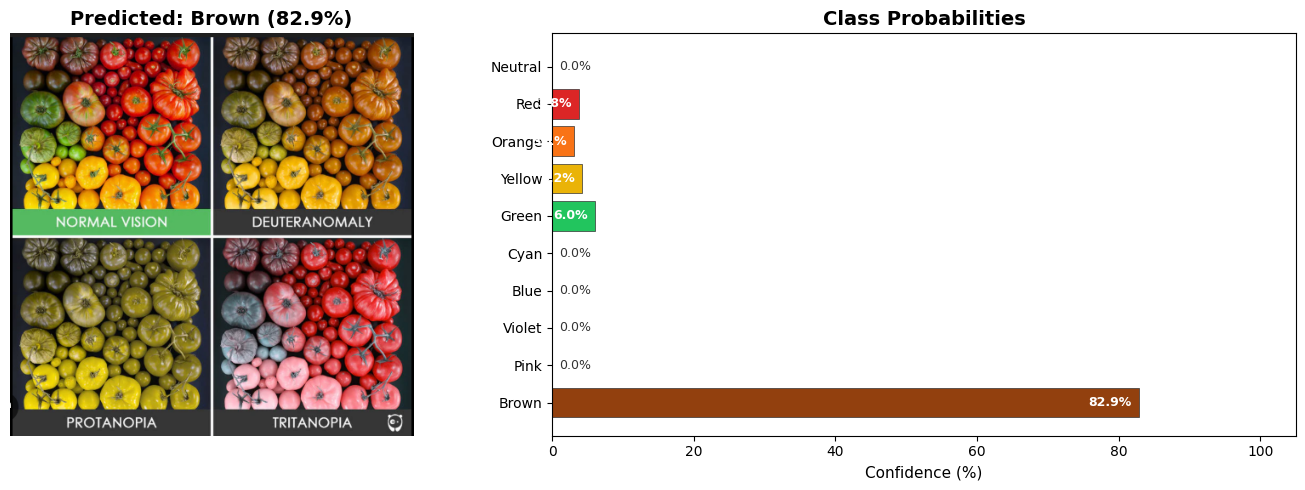


Top-3 predictions:
  #1: Brown (82.9%)
  #2: Green (6.0%)
  #3: Yellow (4.2%)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — TEST WITH test_image.jpg
#
# Loads test_image.jpg, resizes to 128x128, runs the CNN
# identifier, and displays the prediction with confidence bars.
# ═══════════════════════════════════════════════════════════════
import os

# ── Load test image ──────────────────────────────────────────
img_path = 'test_image.jpg'
if not os.path.exists(img_path):
    # Try parent directory
    img_path = '../test_image.jpg'
assert os.path.exists(img_path), f"test_image.jpg not found in {os.getcwd()}"

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)

# ── Run prediction ───────────────────────────────────────────
input_arr = img_resized.astype(np.float32) / 255.0
input_arr = np.expand_dims(input_arr, axis=0)  # (1, 128, 128, 3)

probs = model.predict(input_arr, verbose=0)[0]  # (10,)
pred_class = int(np.argmax(probs))
confidence = probs[pred_class] * 100

print(f"Predicted class: {pred_class} — {CLASS_NAMES[pred_class]}")
print(f"Confidence: {confidence:.1f}%\n")
print("All class probabilities:")
for i, (name, p) in enumerate(zip(CLASS_NAMES, probs)):
    bar = '█' * int(p * 40)
    marker = ' ◄' if i == pred_class else ''
    print(f"  {i:2d} {name:<8s}  {p*100:5.1f}%  {bar}{marker}")

# ── Visualization ────────────────────────────────────────────
# Color map for the bar chart (approximate RGB for each class)
CLASS_COLORS = [
    '#888888',  # Neutral (gray)
    '#DC2626',  # Red
    '#F97316',  # Orange
    '#EAB308',  # Yellow
    '#22C55E',  # Green
    '#06B6D4',  # Cyan
    '#2563EB',  # Blue
    '#7C3AED',  # Violet
    '#EC4899',  # Pink
    '#92400E',  # Brown
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 1.3]})

# Left: test image with prediction label
axes[0].imshow(img_rgb)
axes[0].set_title(f'Predicted: {CLASS_NAMES[pred_class]} ({confidence:.1f}%)',
                  fontsize=14, fontweight='bold')
axes[0].axis('off')

# Right: horizontal bar chart of all class probabilities
bars = axes[1].barh(CLASS_NAMES, probs * 100, color=CLASS_COLORS, edgecolor='#333', linewidth=0.5)
axes[1].set_xlabel('Confidence (%)', fontsize=11)
axes[1].set_title('Class Probabilities', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 105)
axes[1].invert_yaxis()

# Add percentage labels on bars
for bar, p in zip(bars, probs):
    w = bar.get_width()
    if w > 3:
        axes[1].text(w - 1, bar.get_y() + bar.get_height() / 2,
                     f'{w:.1f}%', ha='right', va='center', fontsize=9,
                     color='white', fontweight='bold')
    else:
        axes[1].text(w + 1, bar.get_y() + bar.get_height() / 2,
                     f'{w:.1f}%', ha='left', va='center', fontsize=9, color='#333')

plt.tight_layout()
plt.show()

# ── Top-3 predictions ───────────────────────────────────────
top3 = np.argsort(probs)[::-1][:3]
print("\nTop-3 predictions:")
for rank, idx in enumerate(top3, 1):
    print(f"  #{rank}: {CLASS_NAMES[idx]} ({probs[idx]*100:.1f}%)")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — TFLite INT8 EXPORT
#
# Converts color_identifier.keras → color_identifier.tflite
# Uses INT8 quantization (float32 I/O, quantized weights)
# for small model size (~200-500 KB).
# ═══════════════════════════════════════════════════════════════
import tensorflow as tf
import os

# ── Load the Keras model ─────────────────────────────────────
model_path = 'color_identifier.keras'
assert os.path.exists(model_path), f"{model_path} not found — run Cell 1 first"
model = tf.keras.models.load_model(model_path)

# ── Representative dataset for INT8 calibration ──────────────
# Uses a small batch of random images for quantization calibration
def representative_dataset():
    for _ in range(100):
        data = np.random.rand(1, 128, 128, 3).astype(np.float32)
        yield [data]

# ── Convert to TFLite with INT8 quantization ────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
# Keep float32 input/output for easier integration
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

print("Converting to TFLite INT8 …")
tflite_model = converter.convert()

# ── Save ─────────────────────────────────────────────────────
out_path = 'color_identifier.tflite'
with open(out_path, 'wb') as f:
    f.write(tflite_model)

size_kb = os.path.getsize(out_path) / 1024
print(f"\nSaved → {out_path}")
print(f"Size : {size_kb:.0f} KB")

# ── Verify: quick inference test ─────────────────────────────
interpreter = tf.lite.Interpreter(model_path=out_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"\nInput  shape: {input_details[0]['shape']}  dtype: {input_details[0]['dtype']}")
print(f"Output shape: {output_details[0]['shape']}  dtype: {output_details[0]['dtype']}")

# Run a dummy inference to confirm it works
dummy = np.random.rand(1, 128, 128, 3).astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], dummy)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])
print(f"\nDummy inference output (should sum to ~1.0): {output[0].sum():.4f}")
print(f"Predicted class: {np.argmax(output[0])} — {CLASS_NAMES[np.argmax(output[0])]}")
print("\nTFLite export complete ✓")

Converting to TFLite INT8 …
INFO:tensorflow:Assets written to: C:\Users\HOSHIY~1\AppData\Local\Temp\tmphv0hb7hz\assets


INFO:tensorflow:Assets written to: C:\Users\HOSHIY~1\AppData\Local\Temp\tmphv0hb7hz\assets


Saved artifact at 'C:\Users\HOSHIY~1\AppData\Local\Temp\tmphv0hb7hz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2076806724880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2076806719120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2076806718928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2076806710096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2076806710288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2076806714896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2076806719312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2076806723344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2076290804688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2076290797968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  20

c:\xampp\htdocs\Evala\ReColor\venv\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



Saved → color_identifier.tflite
Size : 314 KB

Input  shape: [  1 128 128   3]  dtype: <class 'numpy.float32'>
Output shape: [ 1 10]  dtype: <class 'numpy.float32'>

Dummy inference output (should sum to ~1.0): 1.0000
Predicted class: 6 — Blue

TFLite export complete ✓


c:\xampp\htdocs\Evala\ReColor\venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
